In [1]:
import os
import sys
import glob
import pickle
import random
import shutil
import zipfile

from numpy.ma.core import squeeze
from tqdm import tqdm
from collections import Counter


import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as opt
from torch.utils.data import Dataset, DataLoader, Subset

### FILES ###
import shutil # delate directory
import zipfile # extract a directory

from sklearn.model_selection import train_test_split # train and test split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [3]:
# DELETE A DIRECTORY FROM CONTENT

folder = "/content/Dataset"

if os.path.exists(folder):
    shutil.rmtree(folder)
    print("Delated directory")
else:
    print("No delated directory")

No delated directory


In [4]:
# RETURN THE ACTIONS FOR EACH DIRECTORY

def getActions(folder_path):

    actions = []

    for filename in os.listdir(folder_path):

        x = filename.split("_")

        action = x[1]
        if len(action) > 1:
            action =  action[0]

        if action not in actions:
            actions.append(action)

    actions.sort()

    print("Actions:", actions)

    return actions

In [5]:
# LISTA DELLE CARTELLE DEL DATASET

ROOT_PATH = "content/Dataset"
#print(os.listdir(ROOT_PATH))
folders = []
for set in os.listdir(ROOT_PATH):

    sets_path = os.path.join(ROOT_PATH, set)

    for folder_name in sorted(os.listdir(sets_path)):

        folder_path = os.path.join(sets_path, folder_name)

        # Considera solo le cartelle
        if not os.path.isdir(folder_path):
            continue

        folders.append(folder_path)

print(folders)

['content/Dataset/doppler_traces_S4_S5/S4', 'content/Dataset/doppler_traces_S4_S5/S5', 'content/Dataset/doppler_traces/S1a', 'content/Dataset/doppler_traces/S1b', 'content/Dataset/doppler_traces/S1c', 'content/Dataset/doppler_traces/S2a', 'content/Dataset/doppler_traces/S2b', 'content/Dataset/doppler_traces/S3a', 'content/Dataset/doppler_traces/S4a', 'content/Dataset/doppler_traces/S4b', 'content/Dataset/doppler_traces/S5a', 'content/Dataset/doppler_traces/S6a', 'content/Dataset/doppler_traces/S6b', 'content/Dataset/doppler_traces/S7a']


In [6]:
# EXTRACT DATASET

complete_dataset = {}

for i in range(0, len(folders)):

    folder = folders[i]
    actions = getActions(folder)
    dataset_array = {}

    for action in actions:
        dataset_array[action] = []

    folder_name = os.path.basename(folder)
    #print(folder_name)
    for action in actions:
        #print(action)
        for filename in os.listdir(folder):
            #print(filename)
            marker = f"_{action}"
            if marker in filename:
                #print("aaa")
                file_path = os.path.join(folder, filename)

                with open(file_path, "rb") as fp:
                    doppler = pickle.load(fp)
                #print(doppler)
                #print(f"{action} add {doppler}")
                dataset_array[action].append(doppler)

    complete_dataset[folder_name] = dataset_array

Actions: ['L']
Actions: ['L']
Actions: ['C', 'E', 'H', 'J', 'L', 'R', 'S', 'W']
Actions: ['C', 'E', 'H', 'J', 'L', 'R', 'S', 'W']
Actions: ['C', 'E', 'H', 'J', 'L', 'R', 'S', 'W']
Actions: ['E', 'J', 'L', 'R', 'W']
Actions: ['E', 'J', 'L', 'R', 'W']
Actions: ['E', 'H', 'J', 'L', 'R', 'S', 'W']
Actions: ['C', 'E', 'H', 'J', 'L', 'R', 'S', 'W']
Actions: ['E', 'J', 'L', 'R', 'W']
Actions: ['C', 'E', 'H', 'J', 'L', 'R', 'W']
Actions: ['C', 'E', 'H', 'J', 'L', 'R', 'S', 'W']
Actions: ['E', 'J', 'L', 'R', 'W']
Actions: ['C', 'E', 'H', 'J', 'L', 'R', 'S', 'W']


In [7]:
# WINDOW OF 1@(340 x 100)

def create_sliding_windows(complete_dataset, window_length=340, stride=340):

  X = []
  y = []
  folders = []
  streams = []

  for folder_name in complete_dataset:
    print("Cartella: ", folder_name)
    dataset = complete_dataset[folder_name]
    all_windows = {}

    for action in dataset:

      #data = np.asarray(dataset[action])
      data = [np.asarray(x) for x in dataset[action]]
      windows_activity = []
      # elements of each action
      #num_streams, time_length, num_features = np.array(data).shape
      #print(f"Action {action} -> Shape of data: {num_streams}, {time_length}, {num_features}")

      num_streams = len(data)
      #print(f"Action {action} -> num_streams: {num_streams}")

      for stream in range(num_streams):

        stream_data = data[stream]
        time_length, num_features = stream_data.shape
        window = []
        # se lo stream è più corto in partenza della grandezza della finestra
        if time_length < window_length:
          print("The dataset is less than window size")
          continue

        start = 0
        end = window_length
        while end <= time_length:
          window = data[stream][start:end,:]
          #windows_stream.append(window)
          X.append(window)
          y.append(action)
          folders.append(folder_name)
          streams.append(stream)
          start += stride
          end += stride

      print(f"Action {action} -> Shape of data: {num_streams}, {time_length}, {num_features}")
      del data

    del dataset

  return X, y, folders, streams

X, y, folders, streams = create_sliding_windows(complete_dataset)


Cartella:  S4
Action L -> Shape of data: 4, 19385, 100
Cartella:  S5
Action L -> Shape of data: 4, 20003, 100
Cartella:  S1a
Action C -> Shape of data: 4, 18766, 100
Action E -> Shape of data: 4, 18700, 100
Action H -> Shape of data: 4, 19064, 100
Action J -> Shape of data: 8, 8708, 100
Action L -> Shape of data: 4, 18842, 100
Action R -> Shape of data: 4, 19269, 100
Action S -> Shape of data: 4, 19009, 100
Action W -> Shape of data: 4, 19295, 100
Cartella:  S1b
Action C -> Shape of data: 4, 18803, 100
Action E -> Shape of data: 4, 18270, 100
Action H -> Shape of data: 4, 18707, 100
Action J -> Shape of data: 8, 8756, 100
Action L -> Shape of data: 4, 19329, 100
Action R -> Shape of data: 4, 19253, 100
Action S -> Shape of data: 4, 18922, 100
Action W -> Shape of data: 4, 18927, 100
Cartella:  S1c
Action C -> Shape of data: 4, 18533, 100
Action E -> Shape of data: 4, 18929, 100
Action H -> Shape of data: 4, 19053, 100
Action J -> Shape of data: 8, 8279, 100
Action L -> Shape of data: 4

In [8]:
index = np.random.randint(0, len(X))
print("Index: ", index)
print(type(X[index]))
print("Element in X: ", X[index].shape)
print("Element in y: ", y[index])
print("Element in folders: ", folders[index])
print("Element in streams: ", streams[index])

Index:  15795
<class 'numpy.ndarray'>
Element in X:  (340, 100)
Element in y:  R
Element in folders:  S6a
Element in streams:  2


In [9]:
label_map = {
    "W": 0,
    "R": 1,
    "J": 2,
    #"J2": 2,
    "L": 3,
    "S": 4,
    "C": 5,
    "H": 6,
    "E": 7
    #"H": 8
}

class DopplerDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        element = self.dataset[idx]
        # Convert to float32
        x = torch.from_numpy(element["data"]).float()

        #normalize
        x = (x - x.mean()) / (x.std() + 1e-8)

        # Add channel dimension -> (1, 340, 100)
        x = x.unsqueeze(0)

        activity = element["label"]

        y = torch.tensor(label_map[activity], dtype=torch.long)

        z = element["folder"]

        w = element["stream"]

        return x, y, z, w



In [10]:
# DATASET, TRAINING, TEST
dataset = [
    {
        "data": data,
        "label": label,
        "folder": folder,
        "stream": stream
    }
    for data, label, folder, stream
    in zip(X, y, folders, streams)
]

dataset_S1 = []
dataset_test_external = []

for sample in dataset:
  if sample["folder"].startswith("S1"):
    dataset_S1.append(sample)
  else:
    dataset_test_external.append(sample)

labels = []

for sample in dataset_S1:
    labels.append(sample["label"])

unique_labels = sorted({s["label"] for s in dataset_S1})
print(unique_labels)


['C', 'E', 'H', 'J', 'L', 'R', 'S', 'W']


In [11]:
train_S1_dataset, test_S1_dataset = train_test_split(
    dataset_S1,
    test_size=0.40,
    random_state=42,
    stratify=labels
)

validation_S1_dataset, test_S1_dataset = train_test_split(
    test_S1_dataset,
    test_size=0.50,
    random_state=42,
    stratify=[s["label"] for s in test_S1_dataset]
)

In [12]:
train_S1_dataset = DopplerDataset(train_S1_dataset)
validation_S1_dataset = DopplerDataset(validation_S1_dataset)
test_S1_dataset = DopplerDataset(test_S1_dataset)

In [13]:
train_labels = [s["label"] for s in dataset_S1]

print(Counter(train_labels))

Counter({'L': 672, 'R': 672, 'H': 668, 'W': 664, 'S': 660, 'C': 656, 'E': 652, 'J': 596})


In [14]:
# CONTENUTO CODICE

print("Dataset: ", dataset[0])
print(dataset[0]["data"].shape)
print("Dataset completo:", len(dataset))
print("Dataset S1:", len(dataset_S1))
print("Dataset test esterno:", len(dataset_test_external))
print("Train S1:", len(train_S1_dataset))
print("Test S1:", len(test_S1_dataset))

#print(train_S1_dataset[0]["data"].shape)
print(train_S1_dataset[0][0].shape)
from collections import Counter

#print(Counter(labels_train))

Dataset:  {'data': array([[0.06309573, 0.06309573, 0.06309573, ..., 0.06309573, 0.06309573,
        0.06309573],
       [0.06309573, 0.06309573, 0.06309573, ..., 0.06309573, 0.06309573,
        0.06309573],
       [0.06309573, 0.06309573, 0.06309573, ..., 0.06309573, 0.06309573,
        0.06309573],
       ...,
       [0.06309573, 0.06309573, 0.06309573, ..., 0.06309573, 0.06309573,
        0.06309573],
       [0.06309573, 0.06309573, 0.06309573, ..., 0.06309573, 0.06309573,
        0.06309573],
       [0.06309573, 0.06309573, 0.06309573, ..., 0.06309573, 0.06309573,
        0.06309573]], shape=(340, 100)), 'label': 'L', 'folder': 'S4', 'stream': 0}
(340, 100)
Dataset completo: 19140
Dataset S1: 5240
Dataset test esterno: 13900
Train S1: 3144
Test S1: 1048
torch.Size([1, 340, 100])


In [15]:
# DATA AUGMENTATION

def augmentation(x):
    x = x.clone()
    #Gaussian noise
    if torch.rand(1) < 0.5:
        sigma = torch.empty(1).uniform_(0.01,0.03) * x.std()
        x += sigma * torch.randn_like(x)
    #Amplitude scaling
    if torch.rand(1) < 0.5:
        scale = torch.empty(1).uniform_(0.9,1.1)
        x *= scale
    #Time shift
    if torch.rand(1) < 0.5:
        shift = torch.randint(-8,9,(1,)).item()
        x = torch.roll(x,shifts=shift, dims=1)

    return x


In [16]:
class AugmentedDataset(Dataset):

    def __init__(self, base_dataset, augment=True):
        self.base_dataset = base_dataset
        self.augment = augment

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        x, y, z, w = self.base_dataset[idx]
        if self.augment:
            x = augmentation(x)
        return x, y, z, w


aug_train_S1_dataset = AugmentedDataset(train_S1_dataset, augment=True)

In [17]:
#Network Definition

NUM_LABELS = 8

class BaseNet(nn.Module):
    def __init__(self):
        super().__init__()

        print("Network Initialized")

        self.branch1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=5, kernel_size=2, stride=2),
            nn.BatchNorm2d(5),
            nn.ReLU())
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=3, kernel_size=1, stride=1, padding='same'),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=2, stride=1, padding='same'),
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.Conv2d(in_channels=6, out_channels=9, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(9),
            nn.ReLU()
        )
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=15, out_channels=3, kernel_size=1, stride=1, padding='same'),
            nn.BatchNorm2d(3),
            nn.ReLU()
        )

        self.block2 = nn.Sequential(
            nn.Dropout(0.3),
            nn.LazyLinear(out_features=NUM_LABELS)
        )

    def forward(self, x):
        b1 = self.branch1(x)
        print("Branch 1:", b1.shape)
        b2 = self.branch2(x)
        print("Branch 2:", b2.shape)
        b3 = self.branch3(x)
        print("Branch 3:", b3.shape)
        h = torch.cat([b1, b2, b3], dim=1)
        print("Concat:", h.shape)
        h = self.block1(h)
        print("Concat:", h.shape)
        h = h.flatten(1)
        print("Flatten:", h.shape)
        out = self.block2(h)
        print("Out:", out.shape)

        return out


In [18]:
batch_size = 128
num_workers = 0
pin_memory = torch.cuda.is_available()

#train_dataloader = DataLoader(train_S1_dataset, batch_size=batch_size, shuffle=True,
#                              num_workers=num_workers, pin_memory=pin_memory)
train_dataloader = DataLoader(aug_train_S1_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin_memory)
valid_dataloader = DataLoader(validation_S1_dataset, batch_size=len(validation_S1_dataset),                              shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
test_dataloader = DataLoader(test_S1_dataset, batch_size=len(test_S1_dataset), shuffle=False,
                             num_workers=num_workers, pin_memory=pin_memory)

In [19]:
model = BaseNet()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

train_loss_log = []
val_loss_log = []
val_acc_log = []
train_acc_log = []

best_val = float("inf")
patience = 5
counter = 0

optimizer = opt.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4) ######learning rate

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

loss_fn = nn.CrossEntropyLoss()

epochs = 25

for epoch in range(epochs):
    model.train()
    print(f"Epoch:{epoch+1}")
    train_iterator = tqdm(train_dataloader)
    train_loss = []
    tr_correct = 0
    tr_total = 0
    for batch_x, batch_y, _, _ in train_iterator:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        y_pred = model(batch_x)

        loss = loss_fn(y_pred, batch_y)

        model.zero_grad()
        loss.backward()
        optimizer.step()
        loss_batch = loss.detach().cpu().numpy()
        train_loss.append(loss_batch)
        #train_iterator.set_description(f"Train loss: {loss.detach().cpu().numpy()}")

        pred = y_pred.argmax(dim=1)
        tr_correct += (pred == batch_y).sum().item()
        tr_total += batch_y.size(0)

    tr_accuracy = tr_correct / tr_total

    train_loss = np.mean(train_loss)
    print(f"AVERAGE TRAIN LOSS: {train_loss}")
    print(f"Accuracy : {tr_accuracy:.2%}")
    train_loss_log.append(train_loss)
    train_acc_log.append(tr_accuracy)

    val_loss= []
    model.eval()
    val_correct = 0
    val_total = 0

    val_iterator = tqdm(valid_dataloader)

    with torch.no_grad():
        for batch_x, batch_y, _, _ in val_iterator:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            out = model(batch_x)

            loss = loss_fn(out, batch_y)
            scheduler.step(loss)

            loss_batch = loss.detach().cpu().numpy()
            val_loss.append(loss_batch)
            pred = out.argmax(dim=1)
            val_correct += (pred == batch_y).sum().item()
            val_total += batch_y.size(0)


        val_accuracy = val_correct / val_total

        val_loss = np.mean(val_loss)
        print(f"AVERAGE VAL LOSS: {np.mean(val_loss)}")
        print(f"Accuracy : {val_accuracy:.2%}")
        val_loss_log.append(val_loss)

        val_acc_log.append(val_accuracy)

        if val_loss < best_val:
            best_val = val_loss
            counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping")
            break


Network Initialized
Epoch:1


  0%|          | 0/25 [00:00<?, ?it/s]

Branch 1: torch.Size([128, 1, 170, 50])
Branch 2: torch.Size([128, 5, 170, 50])


/home/tommaso-jin/Desktop/Human-Activity-Recognition-using-Wi-Fi/.venv/lib/python3.12/site-packages/torch/nn/modules/conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/Convolution.cpp:1101.)
  return F.conv2d(


Branch 3: torch.Size([128, 9, 170, 50])
Concat: torch.Size([128, 15, 170, 50])
Concat: torch.Size([128, 3, 170, 50])
Flatten: torch.Size([128, 25500])
Out: torch.Size([128, 8])


...

AVERAGE TRAIN LOSS: 1.0687686204910278
Accuracy : 58.52%


  0%|          | 0/1 [00:00<?, ?it/s]

Branch 1: torch.Size([1048, 1, 170, 50])
Branch 2: torch.Size([1048, 5, 170, 50])
Branch 3: torch.Size([1048, 9, 170, 50])
Concat: torch.Size([1048, 15, 170, 50])


100%|██████████| 1/1 [00:02<00:00,  2.90s/it]

Concat: torch.Size([1048, 3, 170, 50])
Flatten: torch.Size([1048, 25500])
Out: torch.Size([1048, 8])
AVERAGE VAL LOSS: 1.3279846906661987
Accuracy : 45.71%
Early stopping


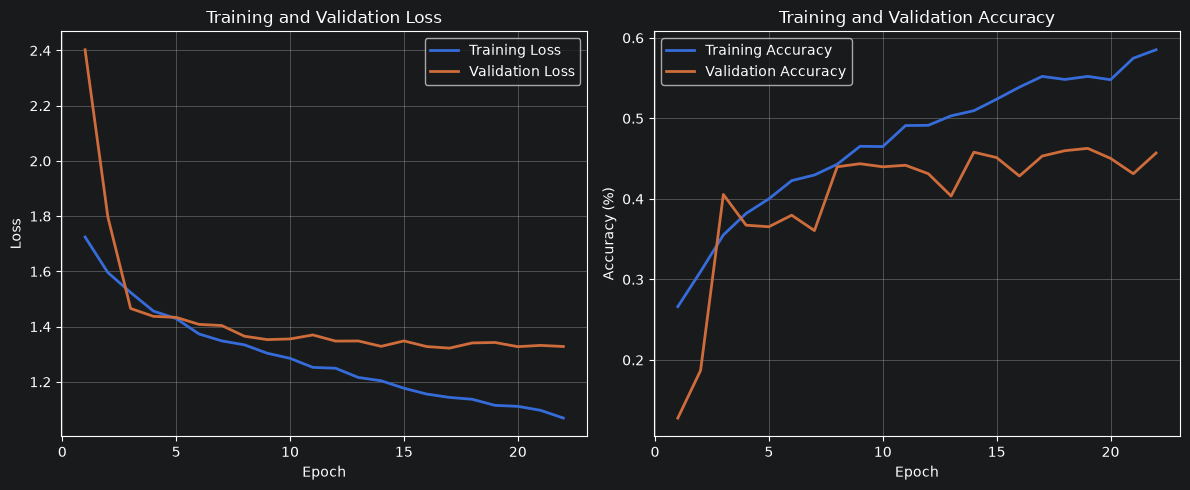

In [20]:
epochs = range(1, len(train_loss_log) + 1)

plt.figure(figsize=(12, 5))

# Losses
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_log, label="Training Loss", linewidth=2)
plt.plot(epochs, val_loss_log, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.grid(True)
plt.legend()

# Accuracies

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc_log, label="Training Accuracy", linewidth=2)
plt.plot(epochs, val_acc_log, label="Validation Accuracy", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
model.load_state_dict(torch.load("best_model.pth"))

model.eval()

all_inputs = []
all_outputs = []
all_labels = []

correct = 0
total = 0
total_loss = 0.0

with torch.no_grad():
    test_iterator = tqdm(test_dataloader)
    for batch_x, batch_y, _, _ in test_iterator:
        out = model(batch_x)
        #print("True label:", batch_y, "Predicted label:", out)
        all_inputs.append(batch_x)
        all_outputs.append(out)
        all_labels.append(batch_y)
        loss = loss_fn(out, batch_y)

        pred = out.argmax(dim=1)
        total_loss += loss.item() * batch_x.size(0)

        correct += (pred == batch_y).sum().item()
        total += batch_y.size(0)

avg_loss = total_loss / total
accuracy = correct / total

all_inputs  = torch.cat(all_inputs)
all_outputs = torch.cat(all_outputs)
all_labels  = torch.cat(all_labels)

test_loss = loss_fn(all_outputs, all_labels)
print(f"AVERAGE TEST LOSS: {test_loss}")
print(f"Test loss: {avg_loss:.4f}")
print(f"Accuracy : {accuracy:.2%}")

  0%|          | 0/1 [00:00<?, ?it/s]

Branch 1: torch.Size([1048, 1, 170, 50])
Branch 2: torch.Size([1048, 5, 170, 50])
Branch 3: torch.Size([1048, 9, 170, 50])
Concat: torch.Size([1048, 15, 170, 50])


100%|██████████| 1/1 [00:02<00:00,  2.98s/it]

Concat: torch.Size([1048, 3, 170, 50])
Flatten: torch.Size([1048, 25500])
Out: torch.Size([1048, 8])
AVERAGE TEST LOSS: 1.3413326740264893
Test loss: 1.3413
Accuracy : 43.51%


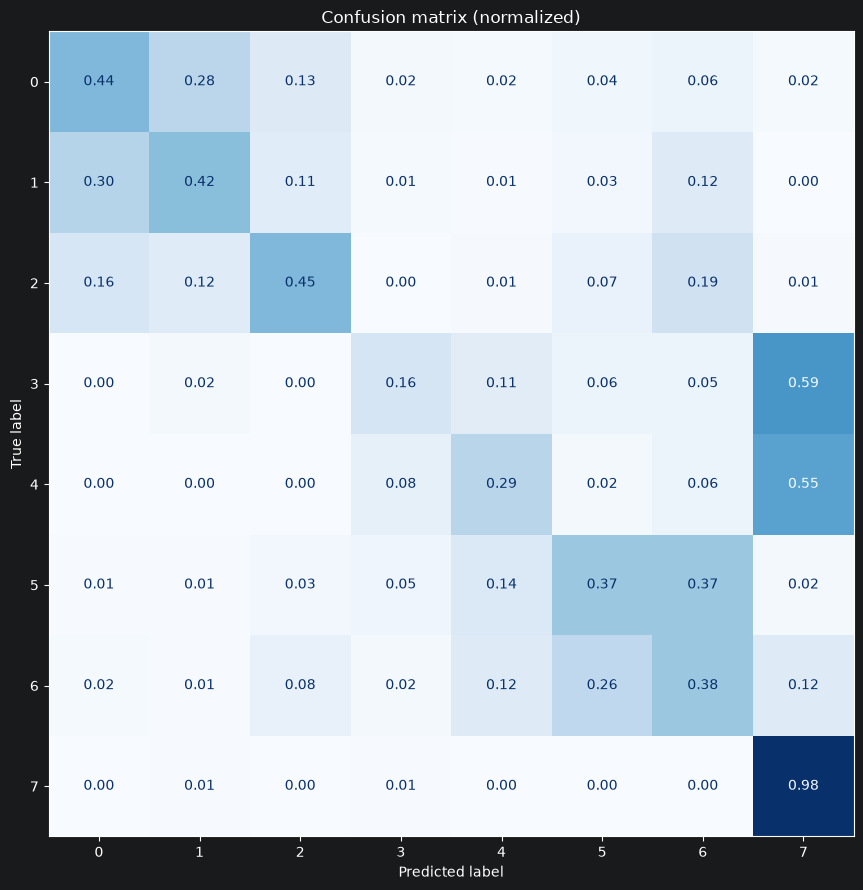

In [22]:
pre_index = torch.tensor([s.argmax() for s in all_outputs])
cm = confusion_matrix(all_labels, pre_index, normalize="true")
class_names = [0, 1, 2, 3, 4, 5, 6, 7]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3, 4, 5, 6, 7])

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
plt.title("Confusion matrix (normalized)")
plt.tight_layout()
plt.show()

In [23]:
"""
Trains a fresh model instance on a TINY fixed subset of the data for
many epochs. If the model can't reach ~100% training accuracy on this
subset, the bug is in the data pipeline / labels / architecture, NOT
in generalization -- fix that before worrying about anything else.

Args:
    model_class: the class (not instance) of your model, e.g. BaseNet
    dataset:     your full training Dataset object (unshuffled subset is fine)
    device:      "cuda" or "cpu"
    n_samples:   how many samples to overfit on (16-32 is plenty)
"""
n_samples = 32
small_ds = Subset(dataset, list(range(n_samples)))
small_loader = DataLoader(DopplerDataset(small_ds), batch_size=1, shuffle=True)

model = BaseNet().to(device)
optimizer = opt.Adam(model.parameters(), lr=0.0001)
loss_fn = nn.CrossEntropyLoss()

print(f"Sanity check: overfitting {n_samples} samples for 200 epochs...")
for epoch in range(200):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    small_iterator=tqdm(small_loader)
    for batch_x, batch_y, _, _ in small_iterator:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()
        y_pred = model(batch_x)
        loss = loss_fn(y_pred, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)
        correct += (y_pred.argmax(dim=1) == batch_y).sum().item()
        total += batch_x.size(0)

    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"  epoch {epoch+1:4d} | loss {total_loss/total:.4f} | "
              f"acc {correct/total:.4f}")

final_acc = correct / total
if final_acc > 0.95:
    print(f"\n✓ PASSED")
else:
    print(f"\n✗ FAILED")

Network Initialized
Sanity check: overfitting 32 samples for 200 epochs...


 19%|█▉        | 6/32 [00:00<00:00, 56.75it/s]

Branch 1: torch.Size([1, 1, 170, 50])
Branch 2: torch.Size([1, 5, 170, 50])
Branch 3: torch.Size([1, 9, 170, 50])
Concat: torch.Size([1, 15, 170, 50])
Concat: torch.Size([1, 3, 170, 50])
Flatten: torch.Size([1, 25500])
Out: torch.Size([1, 8])
Branch 1: torch.Size([1, 1, 170, 50])
Branch 2: torch.Size([1, 5, 170, 50])
Branch 3: torch.Size([1, 9, 170, 50])
Concat: torch.Size([1, 15, 170, 50])
Concat: torch.Size([1, 3, 170, 50])
Flatten: torch.Size([1, 25500])
Out: torch.Size([1, 8])
Branch 1: torch.Size([1, 1, 170, 50])
Branch 2: torch.Size([1, 5, 170, 50])
Branch 3: torch.Size([1, 9, 170, 50])
Concat: torch.Size([1, 15, 170, 50])
Concat: torch.Size([1, 3, 170, 50])
Flatten: torch.Size([1, 25500])
Out: torch.Size([1, 8])
Branch 1: torch.Size([1, 1, 170, 50])
Branch 2: torch.Size([1, 5, 170, 50])
Branch 3: torch.Size([1, 9, 170, 50])
Concat: torch.Size([1, 15, 170, 50])
Concat: torch.Size([1, 3, 170, 50])
Flatten: torch.Size([1, 25500])
Out: torch.Size([1, 8])
Branch 1: torch.Size([1, 1, 

 53%|█████▎    | 17/32 [00:00<00:00, 83.33it/s]

Out: torch.Size([1, 8])
Branch 1: torch.Size([1, 1, 170, 50])
Branch 2: torch.Size([1, 5, 170, 50])
Branch 3: torch.Size([1, 9, 170, 50])
Concat: torch.Size([1, 15, 170, 50])
Concat: torch.Size([1, 3, 170, 50])
Flatten: torch.Size([1, 25500])
Out: torch.Size([1, 8])
Branch 1: torch.Size([1, 1, 170, 50])
Branch 2: torch.Size([1, 5, 170, 50])


...

Branch 1: torch.Size([1, 1, 170, 50])
Branch 2: torch.Size([1, 5, 170, 50])
Branch 3: torch.Size([1, 9, 170, 50])
Concat: torch.Size([1, 15, 170, 50])
Concat: torch.Size([1, 3, 170, 50])
Flatten: torch.Size([1, 25500])
Out: torch.Size([1, 8])
Branch 1: torch.Size([1, 1, 170, 50])
Branch 2: torch.Size([1, 5, 170, 50])
Branch 3: torch.Size([1, 9, 170, 50])
Concat: torch.Size([1, 15, 170, 50])
Concat: torch.Size([1, 3, 170, 50])
Flatten: torch.Size([1, 25500])
Out: torch.Size([1, 8])
Branch 1: torch.Size([1, 1, 170, 50])
Branch 2: torch.Size([1, 5, 170, 50])
Branch 3: torch.Size([1, 9, 170, 50])
Concat: torch.Size([1, 15, 170, 50])
Concat: torch.Size([1, 3, 170, 50])
Flatten: torch.Size([1, 25500])
Out: torch.Size([1, 8])
Branch 1: torch.Size([1, 1, 170, 50])
Branch 2: torch.Size([1, 5, 170, 50])
Branch 3: torch.Size([1, 9, 170, 50])
Concat: torch.Size([1, 15, 170, 50])
Concat: torch.Size([1, 3, 170, 50])
Flatten: torch.Size([1, 25500])
Out: torch.Size([1, 8])
Branch 1: torch.Size([1, 1, 

 75%|███████▌  | 24/32 [00:00<00:00, 115.62it/s]

Branch 1: torch.Size([1, 1, 170, 50])
Branch 2: torch.Size([1, 5, 170, 50])
Branch 3: torch.Size([1, 9, 170, 50])
Concat: torch.Size([1, 15, 170, 50])
Concat: torch.Size([1, 3, 170, 50])
Flatten: torch.Size([1, 25500])
Out: torch.Size([1, 8])
Branch 1: torch.Size([1, 1, 170, 50])
Branch 2: torch.Size([1, 5, 170, 50])
Branch 3: torch.Size([1, 9, 170, 50])
Concat: torch.Size([1, 15, 170, 50])
Concat: torch.Size([1, 3, 170, 50])
Flatten: torch.Size([1, 25500])
Out: torch.Size([1, 8])
Branch 1: torch.Size([1, 1, 170, 50])
Branch 2: torch.Size([1, 5, 170, 50])
Branch 3: torch.Size([1, 9, 170, 50])
Concat: torch.Size([1, 15, 170, 50])
Concat: torch.Size([1, 3, 170, 50])
Flatten: torch.Size([1, 25500])
Out: torch.Size([1, 8])
Branch 1: torch.Size([1, 1, 170, 50])
Branch 2: torch.Size([1, 5, 170, 50])
Branch 3: torch.Size([1, 9, 170, 50])
Concat: torch.Size([1, 15, 170, 50])
Concat: torch.Size([1, 3, 170, 50])
Flatten: torch.Size([1, 25500])
Out: torch.Size([1, 8])
Branch 1: torch.Size([1, 1, 

100%|██████████| 32/32 [00:00<00:00, 116.65it/s]

Branch 3: torch.Size([1, 9, 170, 50])
Concat: torch.Size([1, 15, 170, 50])
Concat: torch.Size([1, 3, 170, 50])
Flatten: torch.Size([1, 25500])
Out: torch.Size([1, 8])
  epoch  200 | loss 0.0000 | acc 1.0000

✓ PASSED


In [36]:
# Network definition with contrastive learning

NUM_LABELS = 8

class ContrastiveNet(nn.Module):
    def __init__(self):
        super().__init__()

        print("Network Initialized")

        self.branch1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=5, kernel_size=2, stride=2),
            nn.BatchNorm2d(5),
            nn.ReLU())
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=3, kernel_size=1, stride=1, padding='same'),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=2, stride=1, padding='same'),
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.Conv2d(in_channels=6, out_channels=9, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(9),
            nn.ReLU()
        )
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=15, out_channels=3, kernel_size=1, stride=1, padding='same'),
            nn.BatchNorm2d(3),
            nn.ReLU()
        )

        #self.block2 = nn.Sequential(
            #nn.Dropout(0.2),
            #nn.LazyLinear(out_features=NUM_LABELS)
        #)

        #self.classifier = nn.Sequential(
            #nn.Dropout(0.2),
            #nn.Linear(25500, out_features=NUM_LABELS)
        #)

        #self.projection_head = nn.Sequential(
            #nn.Linear(25500, 512),
            #nn.ReLU(),
            #nn.Linear(512, 128)
        #)

        # Classifier: h -> NUM_LABELS logits. Reads h directly -- not the
        # projection output -- so it keeps the full encoder representation.
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.LazyLinear(out_features=NUM_LABELS)
        )

        # Projection head: h -> 128-d embedding, L2-normalized, used ONLY
        # for the contrastive loss. Also reads h directly, in parallel with
        # the classifier -- neither head depends on the other's output.
        self.projection_head = nn.Sequential(
            nn.LazyLinear(512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )



    def forward(self, x):
        b1 = self.branch1(x)
        print("Branch 1:", b1.shape)
        b2 = self.branch2(x)
        print("Branch 2:", b2.shape)
        b3 = self.branch3(x)
        print("Branch 3:", b3.shape)

        h = torch.cat([b1, b2, b3], dim=1)
        print("Concat:", h.shape)

        h = self.block1(h)
        print("Concat:", h.shape)
        h = h.flatten(1)
        print("Flatten:", h.shape)

        logits = self.classifier(h)                              # classification
        proj = nn.functional.normalize(self.projection_head(h), dim=1)  # contrastive embedding

        return logits, proj
        #act = self.classifier(h) # classification
        #print("Out:", out.shape)
        #proj = self.projection_head(h) # projection
        #proj = nn.functional.normalize(proj, dim=1)

        #return act,proj


In [37]:


# CLASS PERSON DATASET

class PersonDataset(Dataset):
    def __init__(self, dataset_people):
        self.dataset_people = dataset_people

    def __len__(self):
        return len(self.dataset_people)

    def __getitem__(self, idx):
        sample = self.dataset_people[idx]

        # Convert to float32
        x = torch.from_numpy(sample["data"]).float()
        # Add channel dimension -> (1, 340, 100)
        x = x.unsqueeze(0)

        activity = torch.tensor(label_map[sample["label"]], dtype=torch.long)

        person = sample["person"]

        folder = sample["folder"]

        # stream = sample["stream"]

        return x, activity, person, folder



In [38]:
# GENERATION OF DATASET WRT PEOPLE

person_map = {
    "S1": 0,
    "S2": 0,
    "S3": 1,
    "S4": 0,
    "S5": 1,
    "S6": 0,
    "S7": 2
}

y_people = []

for folder in folders:

    set_name = folder[:2]
    person = person_map[set_name]

    y_people.append(person)

dataset_people = [
    {
        "data": data,
        "label": label,
        "person": person,
        "folder": folder
    }
    for data, label, person, folder
    in zip(X, y, y_people, folders)
]
'''
dataset_P1 = []
dataset_test_other = []

for sample in dataset_people:
  if sample["folder"].startswith("S1") or sample["folder"].startswith("S2") or sample["folder"].startswith("S4") or sample["folder"].startswith("S6"):
    #print(sample["folder"])
    dataset_P1.append(sample)
  else:
    dataset_test_other.append(sample)

labels_people = []

for sample in dataset_P1:
    labels_people.append(sample["label"])
'''


'\ndataset_P1 = []\ndataset_test_other = []\n\nfor sample in dataset_people:\n  if sample["folder"].startswith("S1") or sample["folder"].startswith("S2") or sample["folder"].startswith("S4") or sample["folder"].startswith("S6"):\n    #print(sample["folder"])\n    dataset_P1.append(sample)\n  else:\n    dataset_test_other.append(sample)\n\nlabels_people = []\n\nfor sample in dataset_P1:\n    labels_people.append(sample["label"])\n'

In [39]:
print(len(dataset_people))

19140


In [40]:
# DATALOADER -> TRAIN E TEST DATA

labels = [
    sample["label"]
   for sample in dataset_people
]

train_data_people, test_data_people = train_test_split(
    dataset_people,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Dim training:", len(train_data_people))
print("Dim test:", len(test_data_people))

train_dataset_people = PersonDataset(train_data_people)
test_dataset_people = PersonDataset(test_data_people)
#train_dataset_people = PersonDataset(dataset_P1)
#test_dataset_people = PersonDataset(dataset_test_other)

train_loader_people = DataLoader(
    train_dataset_people,
    batch_size=64,
    shuffle=True
)

test_loader_people = DataLoader(
    test_dataset_people,
    batch_size=64,
    shuffle=False
)

batch_x, batch_activity, batch_person, batch_folder = next(
    iter(train_loader_people)
)

print("Dati:", batch_x.shape)
print("Attività:", batch_activity.shape)
print("Persone:", batch_person.shape)
print("Cartelle:", len(batch_folder))

print("Persone presenti:", torch.unique(batch_person))



Dim training: 15312
Dim test: 3828
Dati: torch.Size([64, 1, 340, 100])
Attività: torch.Size([64])
Persone: torch.Size([64])
Cartelle: 64
Persone presenti: tensor([0, 1, 2])


In [41]:
# PER OGNI ATTIVITà -> CHE TIPO DI PERSONE

for activity in torch.unique(batch_activity):

    mask = batch_activity == activity
    people = torch.unique(batch_person[mask])

    print(
        f"Attività {activity.item()} "
        f"-> {mask.sum().item()} campioni "
        f"-> persone {people.tolist()}"
    )


Attività 0 -> 7 campioni -> persone [0, 1]
Attività 1 -> 13 campioni -> persone [0, 1]
Attività 2 -> 3 campioni -> persone [0, 2]
Attività 3 -> 16 campioni -> persone [0, 1]
Attività 5 -> 9 campioni -> persone [0]
Attività 6 -> 7 campioni -> persone [0, 1, 2]
Attività 7 -> 9 campioni -> persone [0, 1, 2]


In [42]:
# LOSS FUNCTION NT-XENT-LOSS

def NT_Xent_loss(features, activities, people, temperature=0.5):

    #device = features.device
    #batch_size = features.size(0)
    print(features.shape)

    # Similarity matrix
    cos_sim = torch.matmul(features, features.T) / temperature

    # SELF-MASK
    self_mask = torch.eye(
        cos_sim.shape[0],
        dtype=torch.bool,
        device=cos_sim.device
    )

    # POSITIVE KEYS -> DIFFERENT PEOPLE WITH SAME ACTIVITY
    #same_activity = (activities.unsqueeze(dim=1) == activities.unsqueeze(dim=0))
    same_activity = activities[:, None] == activities[None, :]
    different_people = people[:, None] != people[None, :]
    #different_people = (people.unsqueeze(0) != people.unsqueeze(1))
    positive_keys = same_activity & different_people

    # NEGATIVE KEYS -> DIFFERENT ACTIVITIES
    negative_keys = ~same_activity # & different_people

    # VALID COMPARISON -> POSITIVE OR NEGATIVE (excludes same-person/same-activity ties)
    valid_keys = (positive_keys | negative_keys)
    # IGNORE INVALID COMPARISON -> self, and same-person/same-activity ties
    cos_sim_valid = cos_sim.masked_fill_(self_mask | ~valid_keys, -9e15)

    # DENOMINATOR
    log_denominator = torch.logsumexp(cos_sim_valid, dim=1)

    # POSITIVE SIMILARITIES
    positive_similarities = cos_sim.masked_fill(~positive_keys, 0.0)
    num_positives = positive_keys.sum(dim=1)
    mean_positive_similarity = (positive_similarities.sum(dim=1) / num_positives.clamp_min(1))

    # LOSS FOR EACH ANCHOR
    loss_per_anchor = (-mean_positive_similarity + log_denominator)

    # Use only anchors with at least one positive
    valid_anchors = num_positives > 0
    if not valid_anchors.any():
        return features.sum() * 0.0

    loss = loss_per_anchor[valid_anchors].mean()

    return loss


In [43]:
# SimCLR-style two-view dataset. Returns n_views independently-augmented
# copies of the same sample -- the Doppler analogue of the tutorial's
# ContrastiveTransformations, built on augment_sample (already used and
# tested for DopplerDataset) instead of image-specific transforms like
# RandomHorizontalFlip or ColorJitter, which don't have a meaningful
# equivalent for a Doppler spectrogram (flipping it would reverse time or
# the sign of the Doppler velocity; jitter/hue need 3 color channels).

class SimCLRDopplerDataset(Dataset):
    def __init__(self, base_dataset, n_views=2):
        self.base_dataset = base_dataset
        self.n_views = n_views

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        x, y, z, w = self.base_dataset[idx]
        views = [augmentation(x) for _ in range(self.n_views)]
        return views, y

In [44]:
# SimCLR's InfoNCE / NT-Xent loss (ported from the professor's SimCLR class).
# No activities or people needed: the batch is built as
# [view1_0..view1_{B-1}, view2_0..view2_{B-1}], and the positive for row i
# is always at (i + B) mod 2B -- the OTHER view of the same original sample.
# self_mask.roll(shifts=B, dims=0) constructs exactly that pairing.

def info_nce_loss(features, temperature=0.5):
    cos_sim = torch.matmul(features, features.T) / temperature

    self_mask = torch.eye(cos_sim.shape[0], dtype=torch.bool, device=cos_sim.device)
    cos_sim = cos_sim.masked_fill(self_mask, -9e15)

    pos_mask = self_mask.roll(shifts=cos_sim.shape[0] // 2, dims=0)

    nll = -cos_sim[pos_mask] + torch.logsumexp(cos_sim, dim=-1)
    return nll.mean()

In [45]:
class SupConLoss(nn.Module):
    """Supervised Contrastive Learning: https://arxiv.org/pdf/2004.11362.pdf.
    It also supports the unsupervised contrastive loss in SimCLR"""
    def __init__(self, temperature=0.07, contrast_mode='all',
                 base_temperature=0.07):
        super(SupConLoss, self).__init__()
        self.temperature = temperature
        self.contrast_mode = contrast_mode
        self.base_temperature = base_temperature

    def forward(self, features, labels=None, mask=None):
        """Compute loss for model. If both `labels` and `mask` are None,
        it degenerates to SimCLR unsupervised loss:
        https://arxiv.org/pdf/2002.05709.pdf

        Args:
            features: hidden vector of shape [bsz, n_views, ...].
            labels: ground truth of shape [bsz].
            mask: contrastive mask of shape [bsz, bsz], mask_{i,j}=1 if sample j
                has the same class as sample i. Can be asymmetric.
        Returns:
            A loss scalar.
        """
        device = (torch.device('cuda')
                  if features.is_cuda
                  else torch.device('cpu'))

        if len(features.shape) < 3:
            raise ValueError('`features` needs to be [bsz, n_views, ...],'
                             'at least 3 dimensions are required')
        if len(features.shape) > 3:
            features = features.view(features.shape[0], features.shape[1], -1)

        batch_size = features.shape[0]
        if labels is not None and mask is not None:
            raise ValueError('Cannot define both `labels` and `mask`')
        elif labels is None and mask is None:
            mask = torch.eye(batch_size, dtype=torch.float32).to(device)
        elif labels is not None:
            labels = labels.contiguous().view(-1, 1)
            if labels.shape[0] != batch_size:
                raise ValueError('Num of labels does not match num of features')
            mask = torch.eq(labels, labels.T).float().to(device)
        else:
            mask = mask.float().to(device)

        contrast_count = features.shape[1]
        contrast_feature = torch.cat(torch.unbind(features, dim=1), dim=0)
        if self.contrast_mode == 'one':
            anchor_feature = features[:, 0]
            anchor_count = 1
        elif self.contrast_mode == 'all':
            anchor_feature = contrast_feature
            anchor_count = contrast_count
        else:
            raise ValueError('Unknown mode: {}'.format(self.contrast_mode))

        # compute logits
        anchor_dot_contrast = torch.div(
            torch.matmul(anchor_feature, contrast_feature.T),
            self.temperature)
        # for numerical stability
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        # tile mask
        mask = mask.repeat(anchor_count, contrast_count)
        # mask-out self-contrast cases
        logits_mask = torch.scatter(
            torch.ones_like(mask),
            1,
            torch.arange(batch_size * anchor_count).view(-1, 1).to(device),
            0
        )
        mask = mask * logits_mask

        # compute log_prob
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))

        # compute mean of log-likelihood over positive
        # modified to handle edge cases when there is no positive pair
        # for an anchor point.
        # Edge case e.g.:-
        # features of shape: [4,1,...]
        # labels:            [0,1,1,2]
        # loss before mean:  [nan, ..., ..., nan]
        mask_pos_pairs = mask.sum(1)
        mask_pos_pairs = torch.where(mask_pos_pairs < 1e-6, 1, mask_pos_pairs)
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask_pos_pairs

        # loss
        loss = - (self.temperature / self.base_temperature) * mean_log_prob_pos
        loss = loss.view(anchor_count, batch_size).mean()

        return loss

In [46]:

model = ContrastiveNet()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

optimizer = opt.Adam(model.parameters(), lr=0.0001)

criterion_class = nn.CrossEntropyLoss()
criterion_con = SupConLoss(temperature=0.5, base_temperature=0.5)

#temperature = 0.5
lambda_contrastive = 0.1
epochs = 20

simclr_train_dataset = SimCLRDopplerDataset(train_S1_dataset, n_views=2)
# drop_last=True isn't required for info_nce_loss's math (2*B is always even,
# whatever B is) but keeps every batch's negative pool the same size
train_loader_simclr = DataLoader(simclr_train_dataset, batch_size=batch_size, shuffle=True,
                                 drop_last=True, num_workers=num_workers, pin_memory=pin_memory)

for epoch in range(epochs):

    model.train()
    print(f"Epoch: {epoch+1}")
    train_iterator = tqdm(train_loader_simclr)

    correct, total = 0, 0

    for views, batch_activity in train_iterator:

        # views is a list of n_views tensors, each (B, 1, 340, 100)
        n_views = len(views)
        B = batch_activity.size(0)
        imgs = torch.cat(views, dim=0).to(device)                          # (n_views*B, 1, 340, 100)
        batch_activity = batch_activity.to(device)                # (B,) -- one label per ORIGINAL sample
        activity_repeated = batch_activity.repeat(len(views)).to(device)   # (n_views*B,) -- same order as imgs

        # Forward pass
        #activity_logits, projected_features = model(imgs)
        logits, proj = model(imgs)

        # Classification loss -- each view keeps its original sample's activity label
        #classification_loss = criterion(activity_logits, activity_repeated)
        classification_loss = criterion_class(logits, activity_repeated)

        # Contrastive loss -- SimCLR-style, no labels involved
        #contrastive_loss = info_nce_loss(projected_features, temperature=temperature)
        proj_reshaped = proj.view(n_views, B, -1).transpose(0, 1).contiguous()
        contrastive_loss = criterion_con(proj_reshaped, batch_activity)

        # Total loss
        loss = (classification_loss + lambda_contrastive * contrastive_loss)

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # Running training accuracy -- lets you see if the classifier head is
        # actually learning, not just what the loss number happens to be
        preds = logits.argmax(dim=1)
        correct += (preds == activity_repeated).sum().item()
        total += activity_repeated.size(0)

        train_iterator.set_description(
            f"Train loss: {loss.detach().cpu().item():.4f} | "
            f"CE: {classification_loss.detach().cpu().item():.4f} | "
            f"SupCon: {contrastive_loss.detach().cpu().item():.4f}"
            f"acc: {correct/total:.4f}"
        )
    print(f"Epoch {epoch+1} train accuracy: {correct/total:.4f} "
          f"(random-chance baseline for {NUM_LABELS} classes: {1/NUM_LABELS:.4f})")

#batch_x, batch_y, _, _ = next(iter(train_dataloader))
#batch_x = batch_x.to(device)

#with torch.no_grad():
    #out, z = model(batch_x)

#print("Classificazione:", out.shape)
#print("Proiezione:", z.shape)

Network Initialized
Epoch: 1


  0%|          | 0/24 [00:00<?, ?it/s]

Branch 1: torch.Size([256, 1, 170, 50])
Branch 2: torch.Size([256, 5, 170, 50])
Branch 3: torch.Size([256, 9, 170, 50])
Concat: torch.Size([256, 15, 170, 50])
Concat: torch.Size([256, 3, 170, 50])
Flatten: torch.Size([256, 25500])


Train loss: 2.6822 | CE: 2.1354 | SupCon: 5.4676acc: 0.1133:   4%|▍         | 1/24 [00:03<01:24,  3.68s/it]

Branch 1: torch.Size([256, 1, 170, 50])
Branch 2: torch.Size([256, 5, 170, 50])
Branch 3: torch.Size([256, 9, 170, 50])
Concat: torch.Size([256, 15, 170, 50])
Concat: torch.Size([256, 3, 170, 50])
Flatten: torch.Size([256, 25500])


...

Branch 1: torch.Size([256, 1, 170, 50])
Branch 2: torch.Size([256, 5, 170, 50])
Branch 3: torch.Size([256, 9, 170, 50])
Concat: torch.Size([256, 15, 170, 50])
Concat: torch.Size([256, 3, 170, 50])
Flatten: torch.Size([256, 25500])


Train loss: 1.4355 | CE: 0.9652 | SupCon: 4.7035acc: 0.6374:  96%|█████████▌| 23/24 [00:53<00:02,  2.32s/it]

Branch 1: torch.Size([256, 1, 170, 50])
Branch 2: torch.Size([256, 5, 170, 50])
Branch 3: torch.Size([256, 9, 170, 50])
Concat: torch.Size([256, 15, 170, 50])
Concat: torch.Size([256, 3, 170, 50])
Flatten: torch.Size([256, 25500])


Train loss: 1.3670 | CE: 0.9037 | SupCon: 4.6332acc: 0.6379: 100%|██████████| 24/24 [00:55<00:00,  2.31s/it]

Epoch 20 train accuracy: 0.6379 (random-chance baseline for 8 classes: 0.1250)


In [47]:
# Held-out evaluation. Reuses test_dataloader (built way back with test_S1_dataset --
# plain, unaugmented samples) since the classifier head takes any (N,1,340,100)
# batch regardless of whether it came from the SimCLR two-view pipeline.
# This is the number that actually answers "can it predict the action",
# not the training loss.

model.eval()
correct, total = 0, 0

with torch.no_grad():
    for batch_x, batch_y, _, _ in test_dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        activity_logits, _ = model(batch_x)
        preds = activity_logits.argmax(dim=1)

        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

test_acc = correct / total
print(f"Test accuracy: {test_acc:.4f} (n={total}, random-chance baseline: {1/NUM_LABELS:.4f})")

Branch 1: torch.Size([1048, 1, 170, 50])
Branch 2: torch.Size([1048, 5, 170, 50])
Branch 3: torch.Size([1048, 9, 170, 50])
Concat: torch.Size([1048, 15, 170, 50])
Concat: torch.Size([1048, 3, 170, 50])
Flatten: torch.Size([1048, 25500])
Test accuracy: 0.4408 (n=1048, random-chance baseline: 0.1250)
